In [1]:
import numpy as np
import warnings
import time

import pandas as pd
import random

import numpy.ma as ma
from tqdm import tqdm
from src.traffic_sim import *
import matplotlib.pyplot as plt
from src.sim_params.default import DefaultParams

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_32373/2613181297.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# v2 get virtual trajectory

from math import floor
from math import ceil
def get_virtual_trajectory(speed_field, time_start, space_start, d_time, d_space, direction=-1):
    # Initialize the trajectory mask with zeros
    trajectory_mask = np.zeros_like(speed_field)

    # Let's change the units of the speed field so what we can use it as the slope of the line in the time-space plot
    # d_space is in miles per y_bin, and d_time is in seconds per x_bin 
    # The speed field is in mile per hour
    # Let's convert the speed field to miles per second
    speed_field = speed_field / 3600
    # Now let's account for the direction of the vechicles on the road
    speed_field *= direction
    # and let's convert the speed field to y_bin per x_bin  
    speed_field = speed_field * d_time / d_space

    # Forward propagation
    forward_time_points = []
    forward_space_points = []

    time_current, space_current = time_start, space_start
    while 0 <= time_current < speed_field.shape[1] and 0 <= space_current < speed_field.shape[0]:
        # Store the current points in the trajectory points list
        forward_time_points.append(time_current)
        forward_space_points.append(space_current)
        # Get the speed at the current point
        speed = speed_field[int(space_current), int(time_current)]

        # The speed is the slope of the line in the time-space plot
        # For each time step, let's draw a line from the current point and follow the slope until we reach another bin
        # Let's get the time step to reach the next bin, which is the minimum between the time to reach the next time bin and the time to reach the next space bin
        time_to_next_time_bin = floor(time_current + 1) - time_current
        # and now the time to reach the next space bin
        if direction == 1:
            time_to_next_space_bin = (floor(space_current + 1) - space_current) / speed
        elif direction == -1:
            time_to_next_space_bin = (space_current - ceil(space_current - 1)) / speed
        # Let's get the minimum of the two
        time_step = min(abs(time_to_next_time_bin), abs(time_to_next_space_bin))
        # Let's move to the next point in time and space
        time_current += time_step
        space_current += time_step * speed
    
    
    # Backward propagation
    backward_time_points = []
    backward_space_points = []
    time_current, space_current = time_start, space_start
    while 0 <= time_current < speed_field.shape[1] and 0 <= space_current < speed_field.shape[0]:
        # Store the current points in the trajectory points list
        backward_time_points.append(time_current)
        backward_space_points.append(space_current)
        # Get the speed at the current point
        speed = speed_field[int(space_current), int(time_current)]

        # The speed is the slope of the line in the time-space plot
        # For each time step, let's draw a line from the current point and follow the slope until we reach another bin
        # Let's get the time step to reach the previous bin, which is the minimum between the time to reach the next time bin and the time to reach the next space bin
        time_to_previous_time_bin = time_current - ceil(time_current - 1) 
        # and now the time to reach the previous space bin
        if direction == 1: 
            time_to_previous_space_bin = (space_current - ceil(space_current - 1)) / speed
        elif direction == -1: 
            time_to_previous_space_bin = (floor(space_current + 1) - space_current) / speed
        # Let's get the minimum of the two
        time_step = min(abs(time_to_previous_time_bin), abs(time_to_previous_space_bin))
        # Let's move to the next point in time and space
        time_current -= time_step
        space_current -= time_step * speed
    
    # Let's reverse the backward points and add them to the trajectory points 
    backward_time_points.reverse()
    backward_space_points.reverse()
    
    # and now we add them to the beginning of the time_points and space_points
    time_points = backward_time_points + forward_time_points
    space_points = backward_space_points + forward_space_points

    return time_points, space_points       

In [125]:
def vt_travel_time_stats(macro_velocity_field, time_step=10/3600, num_samples=50, num_segments=15):
    m, time_steps = macro_velocity_field.shape
    # Let's use the get_virtual_trajectory and visualize the results
    x_starts = np.linspace(0, time_steps, num_samples) #np.random.uniform(0, time_steps, num_samples)
    y_starts = [m - 0.0001 for i in range(num_samples)]
    d_time = 4
    d_space =  0.4
    virtual_trajectories = [get_virtual_trajectory(macro_velocity_field, x_start, y_start, d_time, d_space) for x_start, y_start in zip(x_starts, y_starts)]
    # print(len(virtual_trajectories))
    # virtual_trajectories = []
    # for t_points, s_points in virtual_trajectories_old:
    #     if len(s_points) > 0 and s_points[-1] < 0.01:
    #         virtual_trajectories.append((t_points, s_points))
    vt_times = [(time_points[-1] - time_points[0]) * time_step * 60 if len(time_points) > 0 else 0 for time_points, space_points in virtual_trajectories]
    print(f"Mean vehicle travel time: {np.mean(vt_times)} min")
    print(f"Standard deviation of vehicle travel time: {np.std(vt_times, ddof=1)} min")

    # Let's visualize the virtual trajectory
    plt.figure(figsize=(9, 5))
    plt.imshow(macro_velocity_field, aspect='auto', interpolation='None', cmap='RdYlGn', extent=[0, time_steps, 0, m], vmin=0, vmax=120)
    plt.xlim(0, time_steps)
    plt.yticks(np.arange(0, num_segments +1, 3), labels=[f"{i*0.4:.1f}" for i in range(0, num_segments + 1, 3)] )
    plt.xticks(np.arange(0, time_steps + 1, 10), labels=[int(i * 10 / 60) if i % 120 == 0 else None for i in range(0, time_steps+1, 10)])
    plt.colorbar(label='Velocity (km/hr)')
    plt.xlabel('Time (min)')
    plt.ylabel('Space (km)')
    for time_points, space_points in virtual_trajectories:
        plt.plot(time_points, num_segments - np.array(space_points), color='blue', linewidth=1)
    plt.title('Virtual Trajectory Example', fontsize=14)
    plt.grid()
    plt.show()
    return vt_times

In [82]:
# def smooth_inflow(inflow, window_size=5):
#     return np.convolve(inflow, np.ones(window_size)/window_size, mode='same')

def smooth_inflow(inflow, window_size=2):
    # Create averaging kernel
    kernel = np.ones(window_size) / window_size
    
    # Compute asymmetric padding for even window sizes
    pad_left = window_size // 2
    pad_right = window_size - pad_left - 1

    # Pad using boundary values (edge padding)
    if inflow.ndim == 1:
        padded = np.pad(inflow, (pad_left, pad_right), mode='edge')
    else:
        padded = np.pad(inflow, ((pad_left, pad_right), (0, 0)), mode='edge')

    # Convolve along time dimension
    smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, kernel, mode="valid"), axis=0, arr=padded
    )
    return smoothed

In [83]:
# Load data
from src.sim_params.I24_30seg_200mParams import METANET_Params

exp_path = "OCP_sb5" #'OCP_sb3' #"robust_S10_0001" #'updated_cintra' #'test_sb_nonsparse' #
L = 0.4
total_time = 2
time_step = 10/3600
start_time = 0

# density_data = np.load(f'src/sim_params/gt_i24_data/density_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')
# velocity_data = np.load(f'src/sim_params/gt_i24_data/velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')
density_data = np.load(f'i35w_data/i35_southbound/i35_sb5_density_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
velocity_data = np.load(f'i35w_data/i35_southbound/i35_sb5_velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
print(density_data.shape)

true_density_initial = density_data[start_time, 1:-1].reshape(-1)
true_velocity_initial = velocity_data[start_time, 1:-1].reshape(-1)

downstream_density = density_data[0:, -1].reshape(-1)
data_inflow = (velocity_data[0:, 0] * density_data[0:, 0]).reshape(-1)

data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

# Predicted from calibration optimization
v_pred = np.load(f'src/sim_params/{exp_path}/v_pred.npy')[start_time:, :]
rho_pred = np.load(f'src/sim_params/{exp_path}/rho_pred.npy')[start_time:, :]

print("time steps:", downstream_density.shape)
print("num segments:", true_density_initial.shape)
print(v_pred.shape)
# print(true_velocity_initial)
# print(v_pred[0, :])


(720, 23)
time steps: (720,)
num segments: (21,)
(720, 21)


In [84]:
time_steps = downstream_density.shape[0]
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")
num_segments = density_data.shape[1] - 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments # km
try:
    lane_counts = np.load(f'src/sim_params/{exp_path}/lane_num.npy').reshape(-1)
except:
    lane_counts = np.load(f'src/sim_params/{exp_path}/num_lanes.npy').reshape(-1)
#lane_counts = np.load('src/sim_params/200m_10_sec/lane_num.npy').reshape(-1)
# lane_counts = smooth_inflow(lane_counts, window_size=3)
sim_lanes = {i: lane_counts[i] for i in range(num_segments)}
#sim_lanes = {i: 4 for i in range(num_segments)}
print("length of highway:", total_distance, "km")
print(sim_lanes)
downstream_density = downstream_density / sim_lanes[num_segments - 1]
i24params = METANET_Params(path=exp_path, num_segments=num_segments).get_params()

sim_time: 120.0 minutes
length of highway: 8.4 km
{0: 2.0, 1: 2.0, 2: 2.0, 3: 2.0, 4: 2.0, 5: 2.0, 6: 2.0, 7: 2.1790951382755, 8: 2.0, 9: 2.0, 10: 2.0, 11: 2.0, 12: 2.0, 13: 2.0, 14: 2.0, 15: 2.0, 16: 2.0, 17: 2.0, 18: 2.0, 19: 2.0, 20: 2.0}


In [85]:
true_density_init_norm = np.array([rho_pred[start_time, i] / sim_lanes[i]
                                    for i in range(num_segments)])

init_state = (true_density_init_norm,
                v_pred[start_time, :],
                data_inflow[start_time],
                0)


In [86]:
# Run METANET
from src.traffic_sim_clean import run_metanet_sim
densities, velocities, queue, tts = run_metanet_sim(time_step, L, init_state, data_inflow, downstream_density, 
                                                    i24params, lanes=sim_lanes, plotting=True)

velocities = np.flip(velocities.T, axis=0)

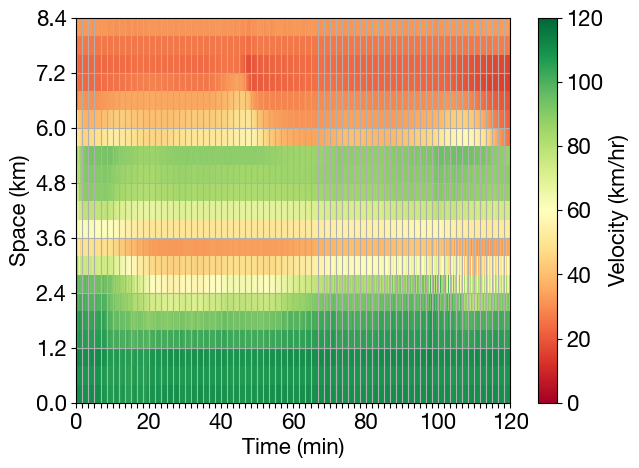

In [117]:
plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 16

plt.figure(figsize=(7, 5))
plt.imshow(velocities, aspect='auto', interpolation='None', cmap='RdYlGn', extent=[0, time_steps, 0, num_segments * L], vmin=0, vmax=120)
plt.yticks(np.arange(0, num_segments * L + L, L*3))
plt.xticks(np.arange(0, time_steps + 1, 10), labels=[int(i * 10 / 60) if i % 120 == 0 else None for i in range(0, time_steps+1, 10)])
plt.colorbar(label='Velocity (km/hr)')
plt.xlabel('Time (min)')
plt.ylabel('Space (km)')
# plt.title("Macroscopic Speed Field")

plt.grid()

Mean vehicle travel time: 22.464999057219224 min
Standard deviation of vehicle travel time: 6.4384777639745705 min


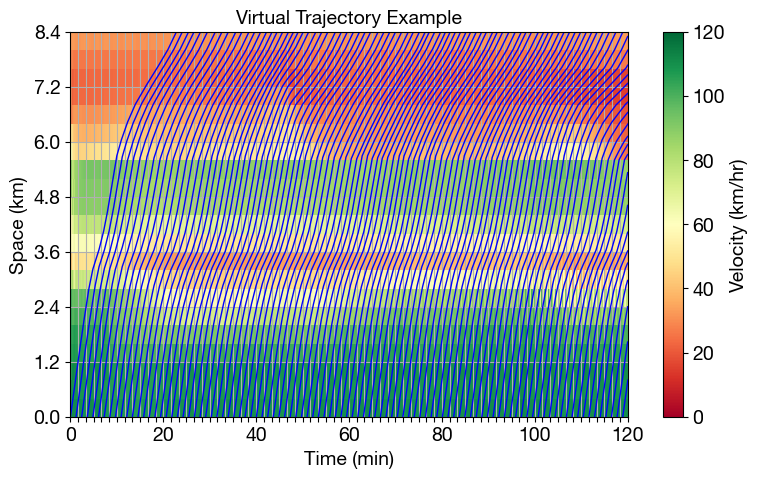

In [162]:
no_control_times = vt_travel_time_stats(velocities, num_samples=100, num_segments=num_segments)

In [169]:
# Run METANET with control
optimal_vsl = np.load(f'src/sim_params/{exp_path}/optimal_vsl_speedlb{0}.npy')
print(optimal_vsl.shape)
#optimal_vsl = pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/holdlen1.csv').to_numpy()
densities_control, velocities_control, queue_control, tts_control = run_metanet_sim(time_step, L, init_state, data_inflow, downstream_density, 
                                                    i24params, vsl_speeds=optimal_vsl, lanes=sim_lanes, plotting=True)

velocities_control = np.flip(velocities_control.T, axis=0)

(720, 21)


Mean vehicle travel time: 15.061117410324087 min
Standard deviation of vehicle travel time: 3.5587358068383934 min


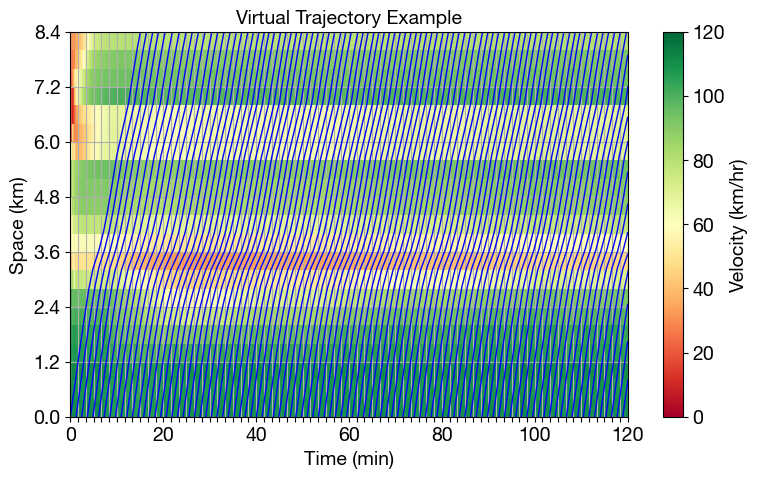

In [170]:
control_times = vt_travel_time_stats(velocities_control, num_samples=100, num_segments=num_segments)

(720, 21)
Mean vehicle travel time: 15.052151325741523 min
Standard deviation of vehicle travel time: 3.5531500459764898 min


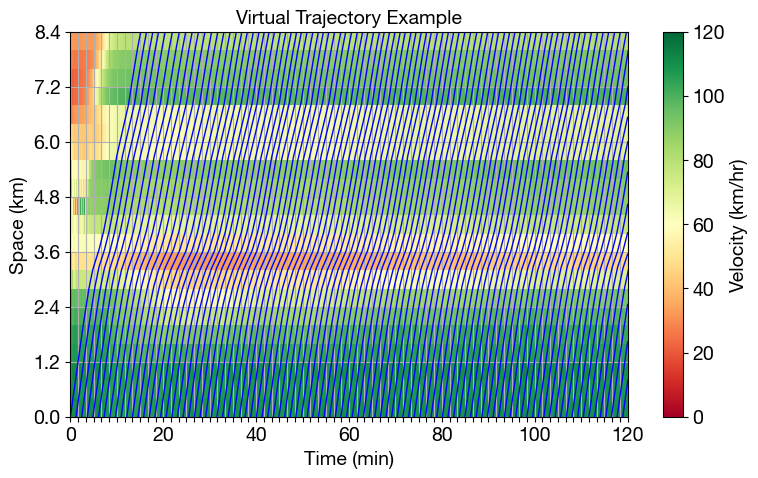

In [171]:
# Run METANET with control
optimal_vsl = np.load(f'src/sim_params/{exp_path}/optimal_vsl_speedlb{60}.npy')
print(optimal_vsl.shape)
#optimal_vsl = pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/holdlen1.csv').to_numpy()
densities_control, velocities_control, queue_control, tts_control = run_metanet_sim(time_step, L, init_state, data_inflow, downstream_density, 
                                                    i24params, vsl_speeds=optimal_vsl, lanes=sim_lanes, plotting=True)

velocities_control = np.flip(velocities_control.T, axis=0)

control_times_60 = vt_travel_time_stats(velocities_control, num_samples=100, num_segments=num_segments)

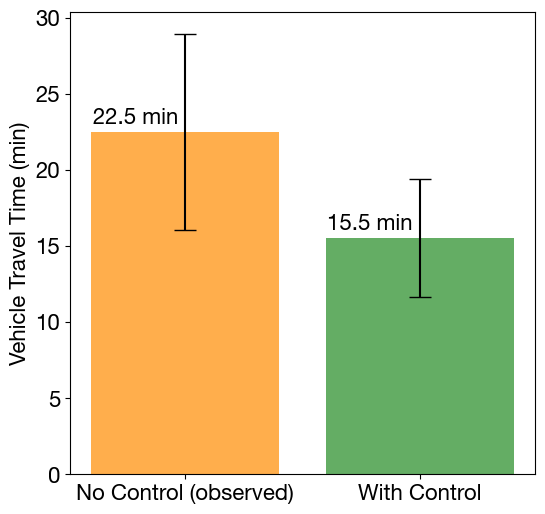

In [150]:
# Data
categories = ["No Control (observed)", "With Control"]
means = [22.46, 15.5]
std_devs = [6.444, 3.87]

# Bar chart with error bars
plt.figure(figsize=(6, 6))
plt.bar(categories, means, yerr=std_devs, capsize=8, color=['darkorange', 'forestgreen'], alpha=0.7)

# Labels and title
plt.ylabel("Vehicle Travel Time (min)")
# plt.title("Comparison of Control Settings")

# Show values on top of bars
for i, v in enumerate(means):
    plt.text(i-0.03, v + 0.6, f"{v:.1f} min", ha='right', fontsize=16, fontweight='bold')

# Show plot
plt.show()

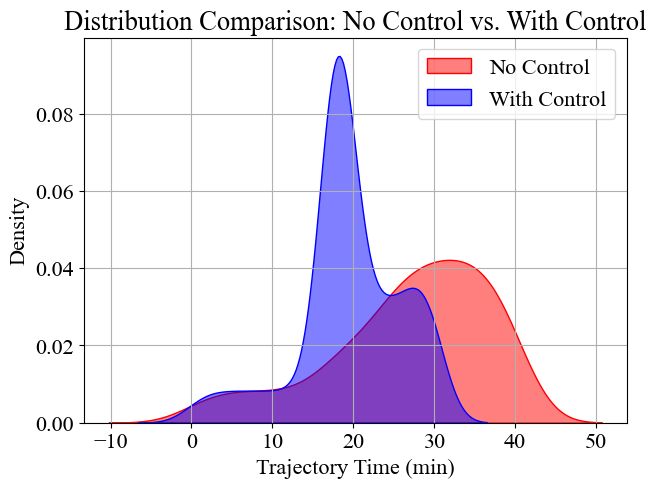

In [39]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16

plt.figure(figsize=(7, 5))
sns.kdeplot(no_control_times, label="No Control", color='red', fill=True, alpha=0.5)
sns.kdeplot(control_times, label="With Control", color='blue', fill=True, alpha=0.5)

plt.xlabel("Trajectory Time (min)")
plt.ylabel("Density")
plt.title("Distribution Comparison: No Control vs. With Control")
plt.legend()
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Travel time reduction per vehicle')

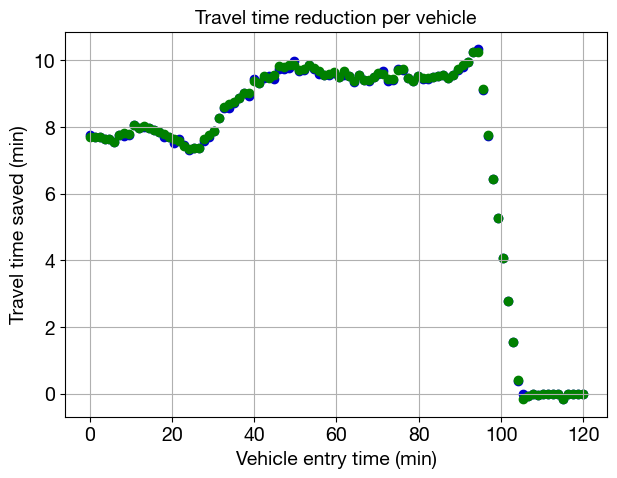

In [173]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Helvetica Neue'

time_steps = optimal_vsl.shape[0]

plt.figure(figsize=(7, 5))
plt.scatter(np.linspace(0, time_steps-1, len(no_control_times)) * 10/60, np.array(no_control_times) - np.array(control_times), color='mediumblue')
plt.scatter(np.linspace(0, time_steps-1, len(no_control_times)) * 10/60, np.array(no_control_times) - np.array(control_times_60), color='green')

plt.grid(True)
plt.ylabel("Travel time saved (min)")
plt.xlabel("Vehicle entry time (min)")
plt.title("Travel time reduction per vehicle", fontsize=14)

In [9]:
sim_time = 1200
hold_len = 1
control_horizon = 6
pred_horizon = 40
optimal_vsl = pd.read_csv(f"optimal_vsl_{sim_time}_holdlen{hold_len}_c{control_horizon}_p{pred_horizon}.csv").to_numpy()


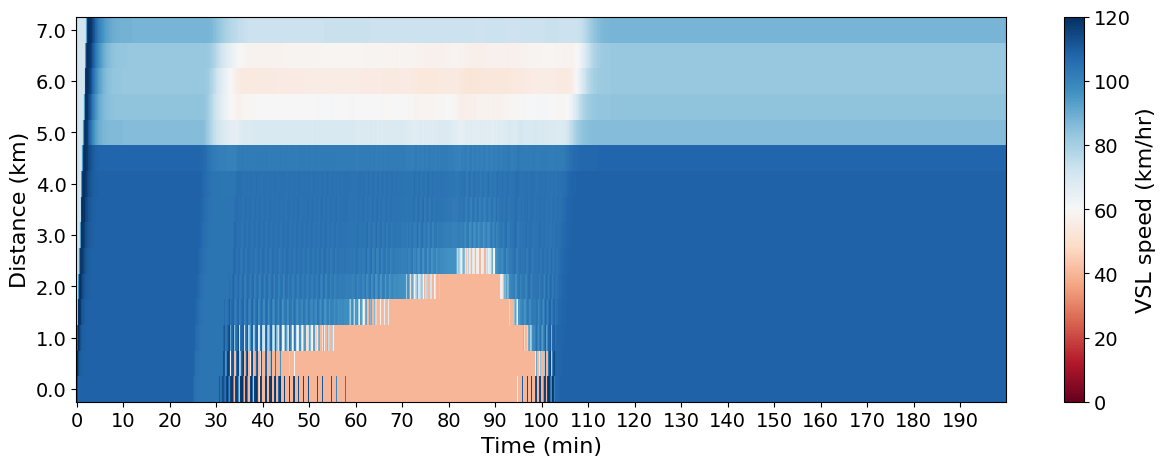

In [11]:
from plotting import *

plot_vsls(optimal_vsl, sim_time, 15, 120, T=10/3600, l=0.5)

In [ ]:
from PIL import Image
import os

# List your images in order
image_files = ['frame1.png', 'frame2.png', 'frame3.png']

# Open the images
images = [Image.open(img) for img in image_files]

# Save as GIF
images[0].save('output.gif',
               save_all=True,
               append_images=images[1:],
               duration=300,   # duration per frame in milliseconds
               loop=0)         # 0 means infinite loop